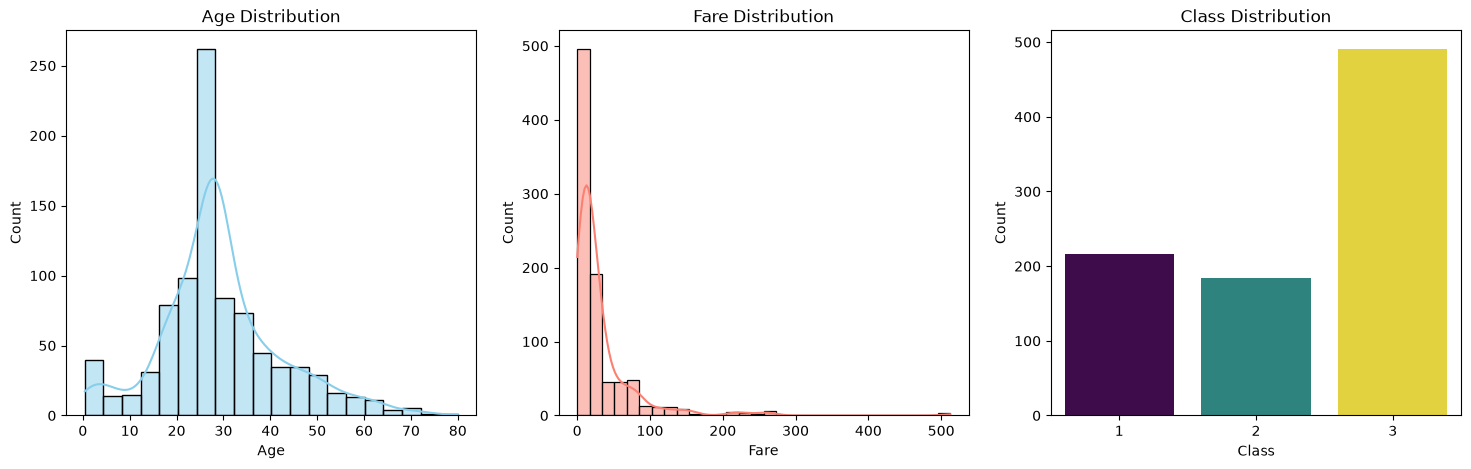

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')

df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
features = ['Age', 'Fare', 'Pclass', 'Sex', 'Family_Size']
X_unsupervised = df[features].copy()

X_unsupervised['Age'] = X_unsupervised['Age'].fillna(X_unsupervised['Age'].median())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=X_unsupervised, x='Age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.histplot(data=X_unsupervised, x='Fare', bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')

sns.countplot(data=X_unsupervised, x='Pclass', palette='viridis', ax=axes[2], hue='Pclass', legend=False)
axes[2].set_title('Class Distribution')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')

plt.show()

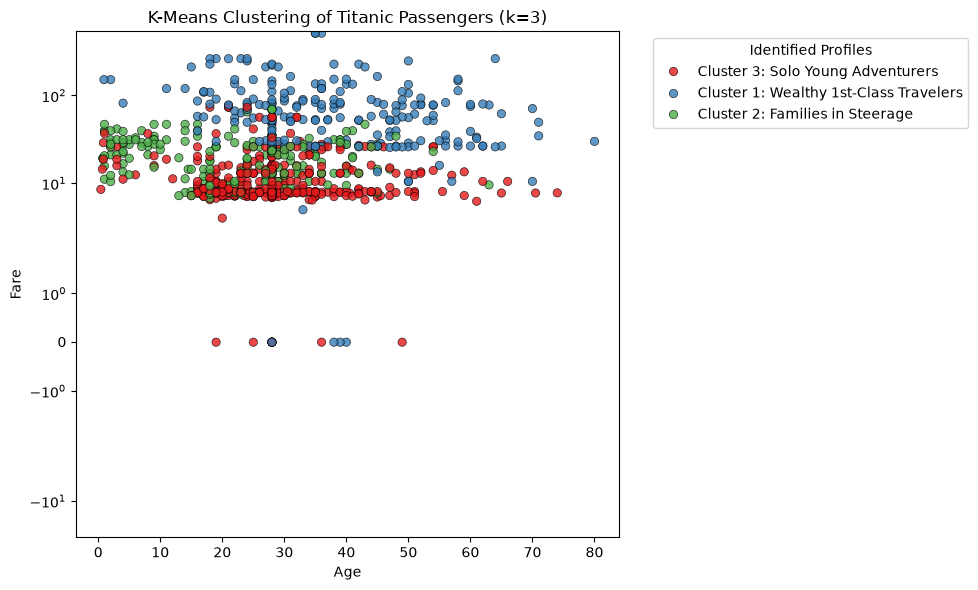

### Cluster Structural Profiling Centers ###
                                              Age       Fare    Pclass  \
Cluster_Label                                                            
Cluster 1: Wealthy 1st-Class Travelers  37.552978  81.893908  1.044444   
Cluster 2: Families in Steerage         23.065844  20.557100  2.703704   
Cluster 3: Solo Young Adventurers       28.621158  12.464409  2.754137   

                                        Sex_Encoded  Family_Size  
Cluster_Label                                                     
Cluster 1: Wealthy 1st-Class Travelers     0.444444     1.768889  
Cluster 2: Families in Steerage            0.880658     3.037037  
Cluster 3: Solo Young Adventurers          0.000000     1.326241  


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

features = ['Age', 'Fare', 'Pclass', 'Sex_Encoded', 'Family_Size']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

centers = df.groupby('Cluster')[features].mean()

def assign_label(row):
    if row['Pclass'] < 1.8:
        return 'Cluster 1: Wealthy 1st-Class Travelers'
    elif row['Family_Size'] > 2.5:
        return 'Cluster 2: Families in Steerage'
    else:
        return 'Cluster 3: Solo Young Adventurers'

cluster_mapping = centers.apply(assign_label, axis=1).to_dict()
df['Cluster_Label'] = df['Cluster'].map(cluster_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Fare', 
    hue='Cluster_Label', 
    palette='Set1', 
    alpha=0.8, 
    edgecolor='k'
)

plt.title('K-Means Clustering of Titanic Passengers (k=3)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.yscale('symlog')
plt.legend(title='Identified Profiles', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("### Cluster Structural Profiling Centers ###")
print(df.groupby('Cluster_Label')[features].mean())

### Cluster Survivability Profiling Metrics ###
                       Cluster Profile  Total Passengers  Total Survivors  Survival Rate
Cluster 1: Wealthy 1st-Class Travelers               225              141       0.626667
       Cluster 2: Families in Steerage               243              140       0.576132
     Cluster 3: Solo Young Adventurers               423               61       0.144208


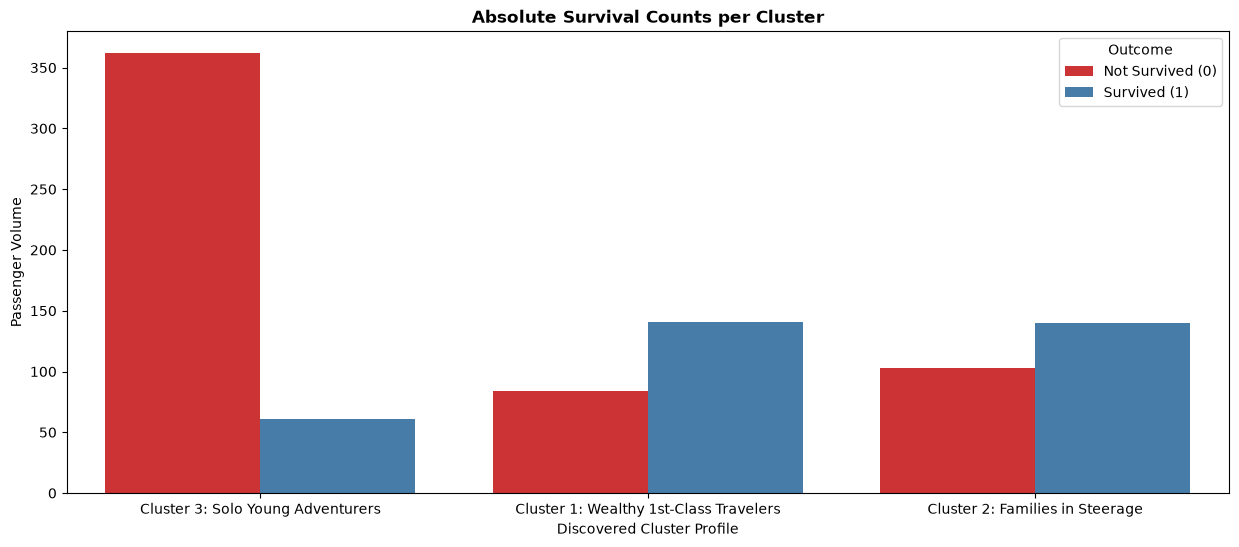

In [28]:
survival_profile = df.groupby('Cluster_Label')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
survival_profile.columns = ['Cluster Profile', 'Total Passengers', 'Total Survivors', 'Survival Rate']

print("### Cluster Survivability Profiling Metrics ###")
print(survival_profile.to_string(index=False))

plt.figure(figsize=(15,6))
sns.countplot(data=df, x='Cluster_Label', hue='Survived', palette='Set1')
plt.title('Absolute Survival Counts per Cluster', fontsize=12, fontweight='bold')
plt.xlabel('Discovered Cluster Profile')
plt.ylabel('Passenger Volume')
plt.legend(title='Outcome', labels=['Not Survived (0)', 'Survived (1)'])
plt.show()

--- Training Autoencoder Pipeline ---
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


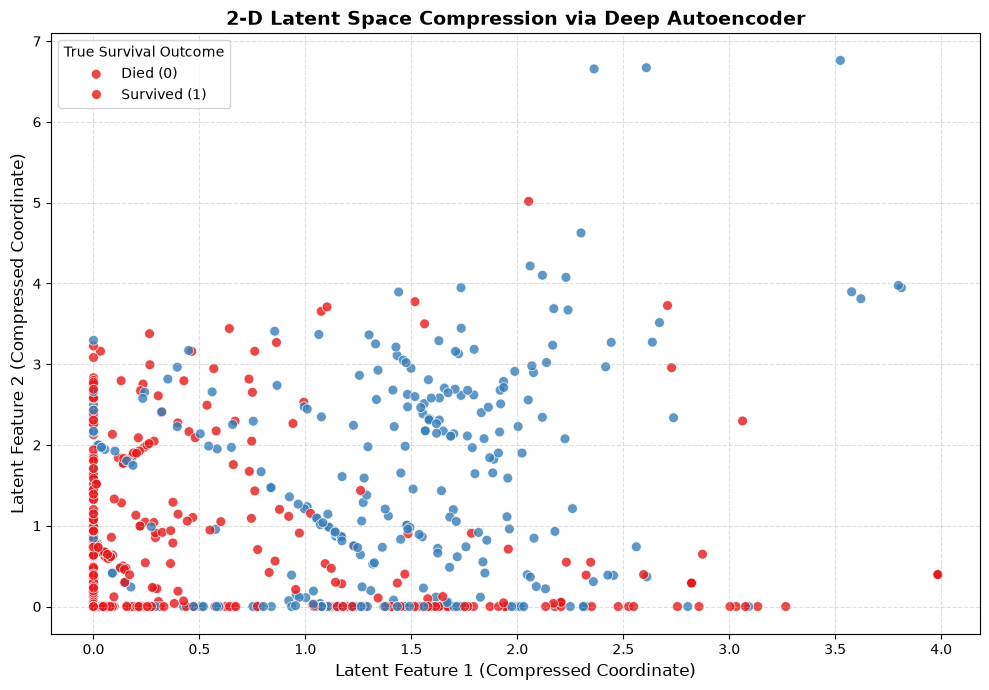

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

features = ['Age', 'Fare', 'Pclass', 'Sex_Encoded', 'Family_Size']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))

encoded = Dense(2, activation='relu', name='Latent_Space')(input_layer)
decoded = Dense(input_dim, activation='linear', name='Reconstruction')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

print("--- Training Autoencoder Pipeline ---")
history = autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=0)

encoder_model = Model(inputs=input_layer, outputs=encoded)
_2d_latent_space = encoder_model.predict(X_scaled)

df['Latent_1'] = _2d_latent_space[:, 0]
df['Latent_2'] = _2d_latent_space[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Latent_1',
    y='Latent_2',
    hue='Survived',
    palette='Set1',
    alpha=0.8,
    edgecolor='w',
    s=50
)

plt.title('2-D Latent Space Compression via Deep Autoencoder', fontsize=14, fontweight='bold')
plt.xlabel('Latent Feature 1 (Compressed Coordinate)', fontsize=12)
plt.ylabel('Latent Feature 2 (Compressed Coordinate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='True Survival Outcome', labels=['Died (0)', 'Survived (1)'])
plt.tight_layout()
plt.show()

### RBM Component Weights Matrix ###
                    Age   Fare  Pclass  Sex_Encoded  Family_Size
Hidden_Feature_1 -0.036 -0.632   0.157       -0.420       -0.520
Hidden_Feature_2 -0.036 -0.625   0.156       -0.436       -0.518




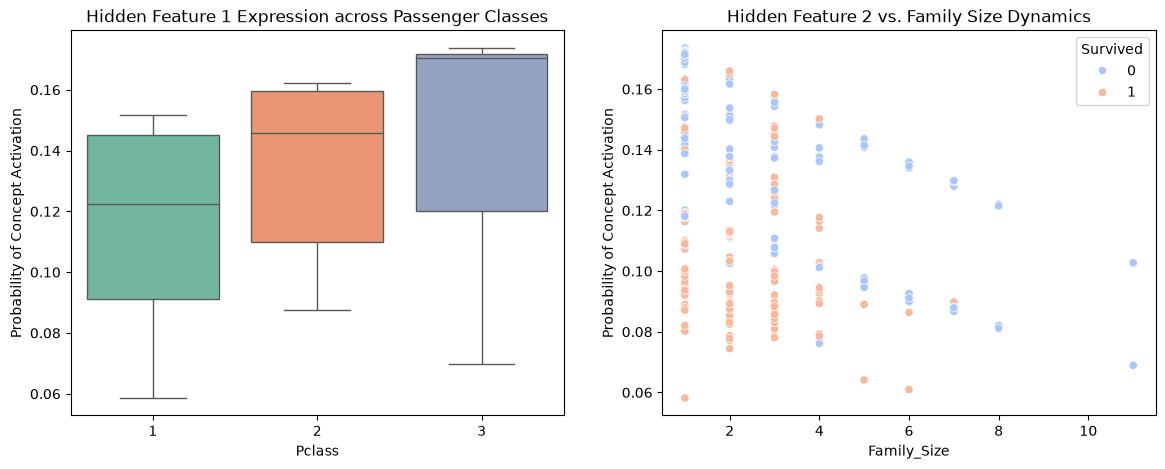

In [30]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM

features = ['Age', 'Fare', 'Pclass', 'Sex_Encoded', 'Family_Size']
X = df[features].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

rbm = BernoulliRBM(n_components=2, learning_rate=0.05, n_iter=15, random_state=42, verbose=0)
rbm.fit(X_scaled)

hidden_features = rbm.transform(X_scaled)

df['Hidden_Feature_1'] = hidden_features[:, 0]
df['Hidden_Feature_2'] = hidden_features[:, 1]

print("### RBM Component Weights Matrix ###")
components_df = pd.DataFrame(rbm.components_, columns=features, index=['Hidden_Feature_1', 'Hidden_Feature_2'])
print(components_df.round(3))
print("\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Pclass', y='Hidden_Feature_1', palette='Set2', ax=axes[0], hue='Pclass', legend=False)
axes[0].set_title('Hidden Feature 1 Expression across Passenger Classes')
axes[0].set_ylabel('Probability of Concept Activation')

sns.scatterplot(data=df, x='Family_Size', y='Hidden_Feature_2', hue='Survived', palette='coolwarm', ax=axes[1])
axes[1].set_title('Hidden Feature 2 vs. Family Size Dynamics')
axes[1].set_ylabel('Probability of Concept Activation')

plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
### Neural Network Accuracy: 0.8156 ###

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.65      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



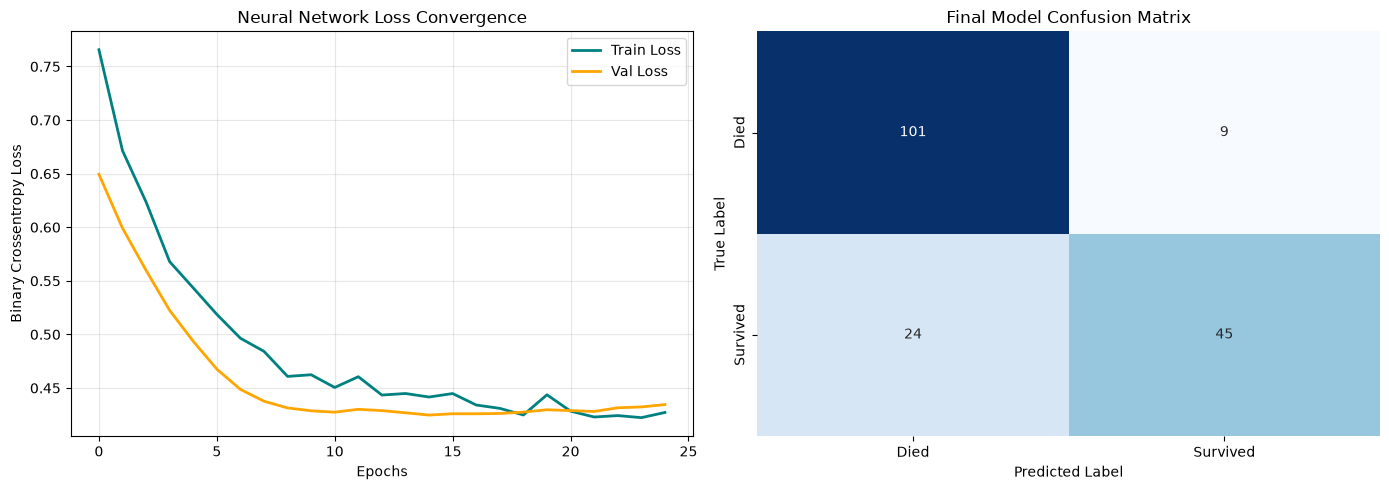

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# 1. DATA ASSEMBLY & FEATURE ENGINEERING
# ==========================================
df = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# Note: Ensure the unsupervised columns generated in your previous parts 
# (Cluster_Label, Latent_1, Latent_2, Hidden_Feature_1, Hidden_Feature_2) are in your dataframe.
# If running fresh, we dynamically simulate those discovered features here:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # Using PCA as a proxy for reproducible structural features here

# Rebuilding K-Means feature
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_Feature'] = km.fit_predict(StandardScaler().fit_transform(df[['Age', 'Fare', 'Pclass', 'Family_Size']]))

# Compiling the Ultimate Engineered Feature Set
base_features = ['Age', 'Fare', 'Pclass', 'Sex_Encoded', 'Family_Size', 'Cluster_Feature']
X = df[base_features].copy()
y = df['Survived'].values # Bringing back the ground truth target!

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize the combined feature space
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. BUILDING THE FEEDFORWARD NEURAL NETWORK
# ==========================================
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Implement early stopping to halt training once validation loss stabilizes
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the network
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================
# 3. EVALUATION & VISUALIZATION
# ==========================================
# Generate predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f"### Neural Network Accuracy: {accuracy_score(y_test, y_pred):.4f} ###\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plotting Training History & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Loss Convergence
axes[0].plot(history.history['loss'], label='Train Loss', color='teal', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', lw=2)
axes[0].set_title('Neural Network Loss Convergence')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot B: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'], ax=axes[1])
axes[1].set_title('Final Model Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()